# Beta-Bernoulli V3: Effect of Prior

1. Data is from simulation
2. Examine the effect of strength of the prior distribution
2. optimize() to get MAT/MLE
3. mcmc by stan

- Bernoulli experiment: $ Y \sim Bernoulli(\theta_\mathrm{true}=.7) $
    - N = 100, fixed
- Prior model: $\theta \sim \mathrm{Beta}(\alpha_0, \beta_0)$
- Posterior (conjugate): $p(\theta \mid Y) = \mathrm{Beta}(\theta \mid \hat\alpha = 1 + N_1, \hat\beta = 1+N_0)$

In [1]:
# Imports and helpers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from math import gamma

## Stan model: Beta-Bernoulli model

In [2]:
# Write Stan model to file
stan_code = r"""
// beta_bernoulli.stan

data {
  int<lower=0> N;                 // number of trials
  array[N] int<lower=0, upper=1> y;     // outcomes
  real<lower=0> alpha0;           // prior alpha
  real<lower=0> beta0;            // prior beta
}

parameters {
  real<lower=0, upper=1> theta;   // success probability
}

model {
  theta ~ beta(alpha0, beta0);    // prior
  y ~ bernoulli(theta);            // likelihood
}
"""

stan_path = Path("beta_bernoulli_v2.stan")
stan_path.write_text(stan_code)
print(f"Wrote Stan model to {stan_path.resolve()}")

Wrote Stan model to C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.stan


## Data Simuation

In [3]:
# Data Simulation
np.random.seed(421012)

theta_true = 0.7
N = 100
Y = np.random.binomial(1, theta_true, size=N)
print(f"Simulated data Y: N={N}, N0={np.sum(Y==0)}, N1={np.sum(Y==1)}")

# prior parameters for Beta distribution
alpha0 = 1.0
beta0 = 1.0

Simulated data Y: N=100, N0=33, N1=67


In [4]:
def likelihood(theta, y):
    """Compute the likelihood of the data given theta."""
    n1 = np.sum(y)
    n0 = len(y) - n1
    return (theta**n1 * (1 - theta)**n0)

## Sample with cmdstanpy

We compile and sample using cmdstanpy. If CmdStan is not installed, uncomment the install step.


In [5]:
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan
model = CmdStanModel(stan_file=str(stan_path))

data = {
            "N": int(N),
            "y": Y.astype(int).tolist(),
            "alpha0": float(alpha0),
            "beta0": float(beta0),
}

fit = model.sample(data=data, iter_sampling=1000)

theta_samples = fit.stan_variable("theta")

fit.summary()

C:\Users\yongd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
22:24:23 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.stan to exe file C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.exe
22:24:30 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Documents\git\Matsuura2022_Bayesian_Statistical_Modeling\yndk\bernoulli\beta_bernoulli_v2.exe
22:24:31 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status



chain 1 |▍         | 00:00 Status

chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling 


22:24:31 - cmdstanpy - INFO - CmdStan done processing.


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-65.409900,0.015930,0.699932,0.305204,-66.734400,-65.148300,-64.926400,2013.55,2243.43,55932.0,1.00171
theta,0.668251,0.001237,0.045521,0.045934,0.592356,0.669334,0.740162,1346.71,1991.48,37408.5,1.00255


## MAP
1. Mode of the posterior if the posterior is $p(\theta|Y) = beta(\theta|\alpha,\beta)$
    $$
        \hat\theta_{MAP} = \frac{\alpha - 1}{\alpha-1 + \beta -1}
    $$

2. Numerical optimization can be used to get approximate estimate:

    `model.optimize(data=data)`


* Since we know the closed-form posterior distribution as a beta distribution, we can compute the two estimates. They should be the same within a numerical accuracy.

In [6]:
result = model.optimize(data=data)
theta_map = result.optimized_params_dict.get("theta", None)
print("theta_hat_MAP:", theta_map)


22:24:31 - cmdstanpy - INFO - Chain [1] start processing
22:24:31 - cmdstanpy - INFO - Chain [1] done processing


theta_hat_MAP: 0.66999644


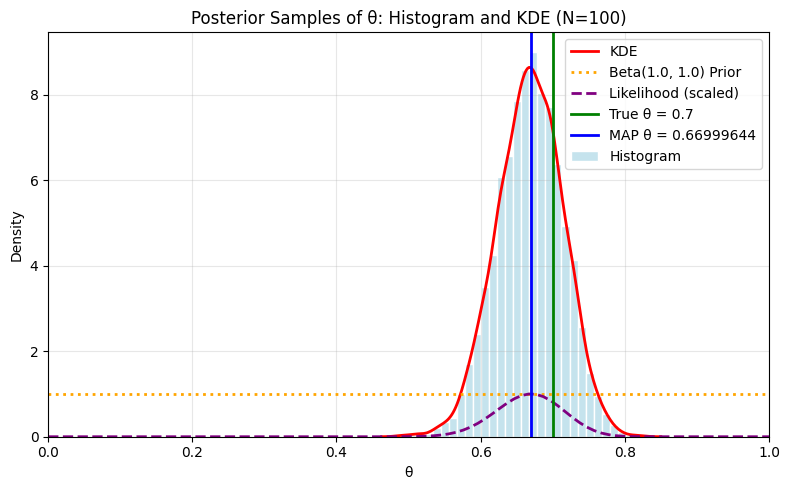

In [7]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples, color="red", linewidth=2, label="KDE")

# Prior distribution plot
from scipy.stats import beta
x = np.linspace(0, 1, 100)
prior_pdf = beta.pdf(x, a=alpha0, b=beta0)
plt.plot(x, prior_pdf, color="orange", linestyle=":", linewidth=2, label=f"Beta({alpha0}, {beta0}) Prior")

# Likelihood plot (scaled for visibility)
likelihood_vals = likelihood(x, Y)
plt.plot(x, likelihood_vals / np.max(likelihood_vals) * np.max(prior_pdf), color="purple", linestyle="--", linewidth=2, label="Likelihood (scaled)")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="-", linewidth=2, label=f"True θ = {theta_true}")
plt.axvline(theta_map, color="blue", linestyle="-", linewidth=2, label=f"MAP θ = {theta_map}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---

## Data Simuation: $\alpha_0=10, \beta_0=10$

In [8]:
# prior parameters for Beta distribution
alpha0 = 10.0
beta0 = 10.0

## Sample with cmdstanpy

We compile and sample using cmdstanpy. If CmdStan is not installed, uncomment the install step.


In [9]:
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan
# model = CmdStanModel(stan_file=str(stan_path))

data = {
            "N": int(N),
            "y": Y.astype(int).tolist(),
            "alpha0": float(alpha0),
            "beta0": float(beta0),
}

fit_10 = model.sample(data=data, iter_sampling=1000)

theta_samples_10 = fit_10.stan_variable("theta")

fit_10.summary()

22:24:31 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed                     


22:24:31 - cmdstanpy - INFO - CmdStan done processing.


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-78.777400,0.016796,0.676062,0.307941,-80.14420,-78.51800,-78.296200,1736.43,2009.55,43410.7,1.00104
theta,0.642637,0.001153,0.042717,0.043074,0.57067,0.64326,0.710825,1396.66,1843.28,34916.5,1.00125


## MAP
1. Mode of the posterior if the posterior is $p(\theta|Y) = beta(\theta|\alpha,\beta)$
    $$
        \hat\theta_{MAP} = \frac{\alpha - 1}{\alpha-1 + \beta -1}
    $$

2. Numerical optimization can be used to get approximate estimate:

    `model.optimize(data=data)`


* Since we know the closed-form posterior distribution as a beta distribution, we can compute the two estimates. They should be the same within a numerical accuracy.

In [10]:
result = model.optimize(data=data)
theta_map = result.optimized_params_dict.get("theta", None)
print("theta_hat_MAP:", theta_map)


22:24:32 - cmdstanpy - INFO - Chain [1] start processing
22:24:32 - cmdstanpy - INFO - Chain [1] done processing


theta_hat_MAP: 0.6440667


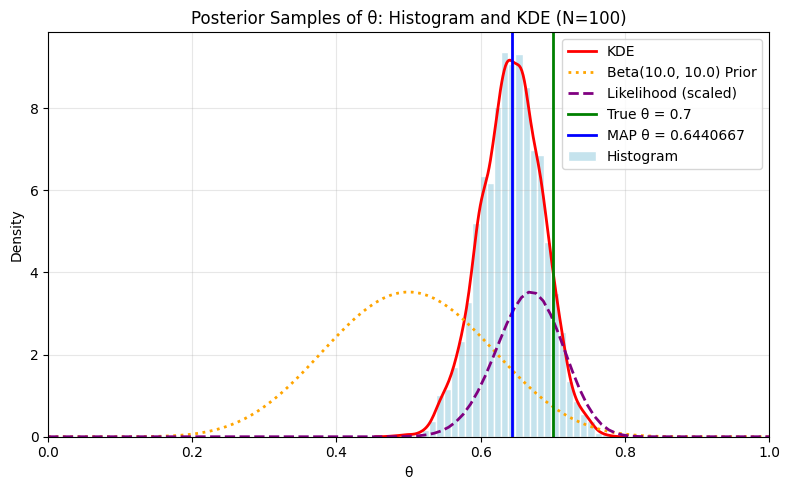

In [11]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples_10, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples_10, color="red", linewidth=2, label="KDE")

# Prior distribution plot
from scipy.stats import beta
x = np.linspace(0, 1, 100)
prior_pdf = beta.pdf(x, a=alpha0, b=beta0)
plt.plot(x, prior_pdf, color="orange", linestyle=":", linewidth=2, label=f"Beta({alpha0}, {beta0}) Prior")

# Likelihood plot (scaled for visibility)
likelihood_vals = likelihood(x, Y)
plt.plot(x, likelihood_vals / np.max(likelihood_vals) * np.max(prior_pdf), color="purple", linestyle="--", linewidth=2, label="Likelihood (scaled)")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="-", linewidth=2, label=f"True θ = {theta_true}")
plt.axvline(theta_map, color="blue", linestyle="-", linewidth=2, label=f"MAP θ = {theta_map}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---

## Data Simuation $\alpha_0 = \beta_0 = 100$

In [12]:
# Data Simulation
np.random.seed(42)

# theta_true = 0.7
# N = 1000
# Y = np.random.binomial(1, theta_true, size=N)

# prior parameters for Beta distribution
alpha0 = 100.0
beta0 = 100.0

## Sample with cmdstanpy

We compile and sample using cmdstanpy. If CmdStan is not installed, uncomment the install step.


In [13]:
from cmdstanpy import CmdStanModel, cmdstan_path, install_cmdstan
model = CmdStanModel(stan_file=str(stan_path))

data = {
            "N": int(N),
            "y": Y.astype(int).tolist(),
            "alpha0": float(alpha0),
            "beta0": float(beta0),
}

fit_100 = model.sample(data=data, iter_sampling=1000)

theta_samples_100 = fit_100.stan_variable("theta")

fit_100.summary()

22:24:32 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |▍         | 00:00 Status
chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed


22:24:32 - cmdstanpy - INFO - CmdStan done processing.


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-206.525000,0.015727,0.720802,0.317729,-207.980000,-206.243000,-206.015000,2029.99,2865.43,56388.6,1.00204
theta,0.555508,0.000796,0.028920,0.028872,0.508736,0.555848,0.603255,1336.22,2344.81,37117.1,1.00177


## MAP
1. Mode of the posterior if the posterior is $p(\theta|Y) = beta(\theta|\alpha,\beta)$
    $$
        \hat\theta_{MAP} = \frac{\alpha - 1}{\alpha-1 + \beta -1}
    $$

2. Numerical optimization can be used to get approximate estimate:

    `model.optimize(data=data)`


* Since we know the closed-form posterior distribution as a beta distribution, we can compute the two estimates. They should be the same within a numerical accuracy.

In [14]:
result = model.optimize(data=data)
theta_map = result.optimized_params_dict.get("theta", None)
print("theta_hat_MAP:", theta_map)


22:24:32 - cmdstanpy - INFO - Chain [1] start processing
22:24:32 - cmdstanpy - INFO - Chain [1] done processing


theta_hat_MAP: 0.55704697


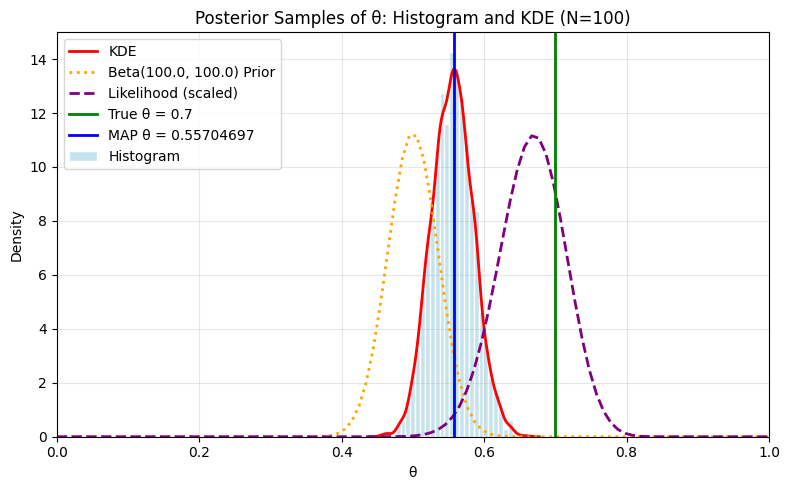

In [15]:
# Create histogram and KDE plot of theta_samples
plt.figure(figsize=(8, 5))

# Histogram with density
sns.histplot(theta_samples_100, stat="density", bins=30, color="lightblue", edgecolor="white", alpha=0.7, label="Histogram")

# KDE plot
sns.kdeplot(theta_samples_100, color="red", linewidth=2, label="KDE")

# Prior distribution plot
from scipy.stats import beta
x = np.linspace(0, 1, 100)
prior_pdf = beta.pdf(x, a=alpha0, b=beta0)
plt.plot(x, prior_pdf, color="orange", linestyle=":", linewidth=2, label=f"Beta({alpha0}, {beta0}) Prior")

# Likelihood plot (scaled for visibility)
likelihood_vals = likelihood(x, Y)
plt.plot(x, likelihood_vals / np.max(likelihood_vals) * np.max(prior_pdf), color="purple", linestyle="--", linewidth=2, label="Likelihood (scaled)")

# Add vertical line for true theta
plt.axvline(theta_true, color="green", linestyle="-", linewidth=2, label=f"True θ = {theta_true}")
plt.axvline(theta_map, color="blue", linestyle="-", linewidth=2, label=f"MAP θ = {theta_map}")

plt.xlabel("θ")
plt.ylabel("Density")
plt.title(f"Posterior Samples of θ: Histogram and KDE (N={N})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

End.